# 05 - Analysis, Visualization & Deutschlandticket Adoption Scoring

This notebook completes the analysis by:
- Analyzing commute time distributions and grouping employees into time buckets (round-trip)
- Calculating financial attractiveness of Deutschlandticket adoption under different cost scenarios
- Computing adoption scores based on both time and financial factors
- Creating visualizations of the results
- Summary findings and key insights

**Note:** This analysis uses round-trip commute times (morning + evening journeys) instead of one-way times.

In [21]:
# Import the libraries we need for analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
import folium
from folium import plugins
import json

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [22]:
# Load the optimal commute results from the routing notebook
commute_df = pd.read_csv('data/synthetic_employees_with_optimal_commutes.csv')
print(f"Loaded {len(commute_df)} employees with optimal commute data")
print(f"Available columns: {commute_df.columns.tolist()}")

# Check if coordinates are available (might have duplicate columns from merges)
print(f"\nCoordinate columns available:")
print(f"  snapped_latitude_x: {'✓' if 'snapped_latitude_x' in commute_df.columns else '✗'}")
print(f"  snapped_longitude_x: {'✓' if 'snapped_longitude_x' in commute_df.columns else '✗'}")
print(f"  snapped_latitude_y: {'✓' if 'snapped_latitude_y' in commute_df.columns else '✗'}")
print(f"  snapped_longitude_y: {'✓' if 'snapped_longitude_y' in commute_df.columns else '✗'}")

# Clean up duplicate coordinate columns if they exist from previous merges
if 'snapped_latitude_x' in commute_df.columns and 'snapped_latitude_y' in commute_df.columns:
    # Remove duplicate _y columns, keep _x columns
    commute_df = commute_df.drop(columns=['snapped_latitude_y', 'snapped_longitude_y'])
    # Rename _x columns back to original names
    commute_df = commute_df.rename(columns={
        'snapped_latitude_x': 'snapped_latitude',
        'snapped_longitude_x': 'snapped_longitude'
    })
    print("Cleaned up duplicate coordinate columns")

print(f"\nTotal employees: {len(commute_df)}")
print(f"Employees with valid routes: {commute_df['otp_route_found'].sum()}")
print(f"Employees without routes: {(~commute_df['otp_route_found']).sum()}")

# Display sample data to verify
print("\nSample optimal commute data:")
print(commute_df[['employee_id', 'optimal_employee_station', 'optimal_employee_station_rank', 
                   'walk_home_to_station_min', 'transit_time_min', 'walk_station_to_office_min', 
                   'total_commute_min']].head(10))

Loaded 178 employees with optimal commute data
Available columns: ['employee_id', 'name', 'address', 'city', 'postal_code', 'latitude', 'longitude', 'snapped_latitude', 'snapped_longitude', 'optimal_employee_station', 'optimal_employee_station_id', 'optimal_employee_station_rank', 'optimal_office_station', 'optimal_office_station_id', 'optimal_office_station_rank', 'walk_home_to_station_min', 'transit_time_min', 'walk_station_to_office_min', 'total_commute_min', 'otp_route_found', 'car_distance_m', 'car_driving_time_min', 'car_parking_time_min', 'car_total_time_min', 'commute_time_bucket', 'transport_attractiveness', 'monthly_driving_cost', 'financial_attractiveness_Company Pays Full', 'financial_attractiveness_50% Subsidy', 'financial_attractiveness_Employee Pays Full', 'adoption_score_Company Pays Full', 'adoption_score_50% Subsidy', 'adoption_score_Employee Pays Full', 'employee_station', 'employee_station_id', 'employee_station_rank', 'office_station', 'office_station_id', 'office_

In [23]:
# Define time buckets for grouping employees by round-trip commute duration
# Adjusted thresholds for round-trip (double the one-way thresholds)
time_buckets = {
    '0-60 min': (0, 60),
    '60-90 min': (60, 90),
    '90-120 min': (90, 120),
    '120+ min': (120, float('inf'))
}

# Function to categorize employees into time buckets
def categorize_commute_time(time_min):
    if pd.isna(time_min):
        return 'No route'
    for bucket, (min_time, max_time) in time_buckets.items():
        if min_time <= time_min < max_time:
            return bucket
    return '120+ min'

In [24]:
# Commute-time grouping analysis (round-trip)
print("=== Commute-Time Grouping Analysis (Round-Trip) ===")
commute_df['commute_time_bucket'] = commute_df['total_commute_min'].apply(categorize_commute_time)

# Calculate percentages for each bucket
total_with_routes = commute_df['otp_route_found'].sum()
bucket_counts = commute_df[commute_df['otp_route_found']]['commute_time_bucket'].value_counts()
bucket_percentages = (bucket_counts / total_with_routes * 100).round(1)

print(f"\nEmployees with valid routes: {total_with_routes}")
print(f"\nRound-trip commute-time distribution:")
for bucket in ['0-60 min', '60-90 min', '90-120 min', '120+ min']:
    count = bucket_counts.get(bucket, 0)
    percentage = bucket_percentages.get(bucket, 0)
    print(f"{bucket}: {count} employees ({percentage}%)")

print(f"\nEmployees without routes: {(~commute_df['otp_route_found']).sum()} ({(~commute_df['otp_route_found']).sum()/len(commute_df)*100:.1f}%)")

=== Commute-Time Grouping Analysis (Round-Trip) ===

Employees with valid routes: 131

Round-trip commute-time distribution:
0-60 min: 7 employees (5.3%)
60-90 min: 43 employees (32.8%)
90-120 min: 19 employees (14.5%)
120+ min: 62 employees (47.3%)

Employees without routes: 47 (26.4%)


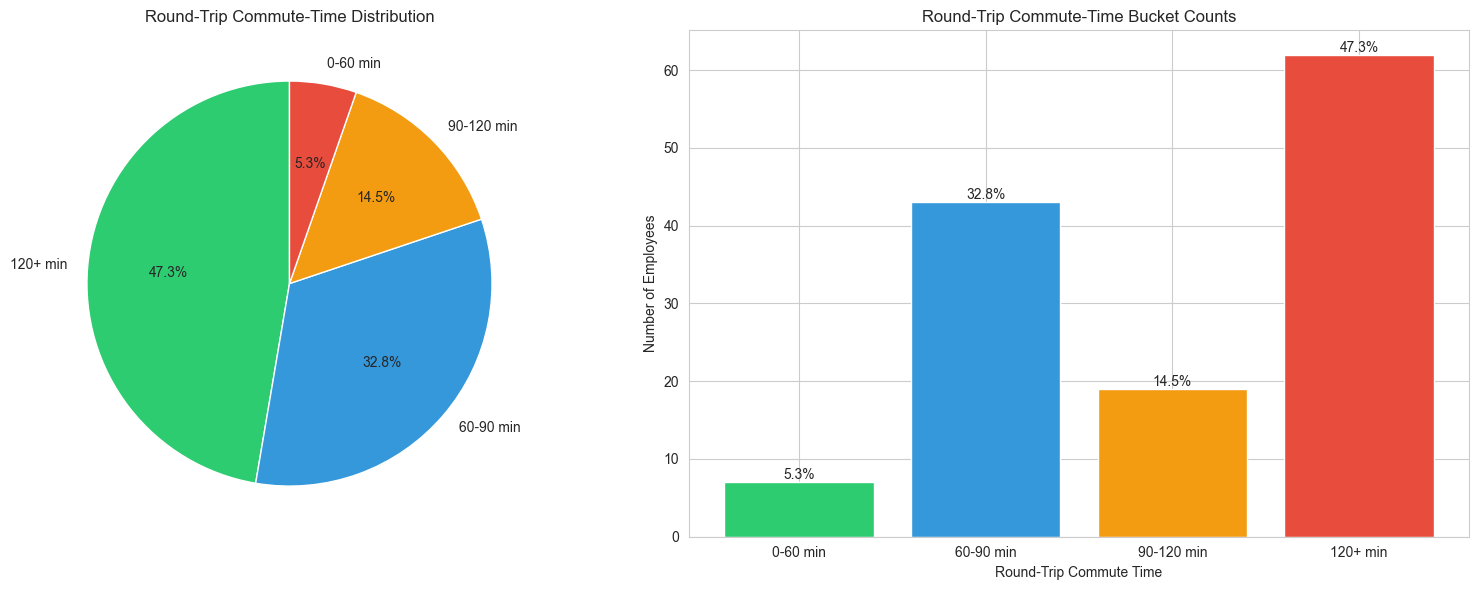

In [25]:
# Create visualization of commute time distribution (round-trip)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart showing distribution
valid_routes = commute_df[commute_df['otp_route_found']]
bucket_data = valid_routes['commute_time_bucket'].value_counts()
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

ax1.pie(bucket_data, labels=bucket_data.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Round-Trip Commute-Time Distribution')

# Bar chart showing counts
bucket_order = ['0-60 min', '60-90 min', '90-120 min', '120+ min']
bucket_counts_ordered = [bucket_counts.get(bucket, 0) for bucket in bucket_order]
bucket_percentages_ordered = [bucket_percentages.get(bucket, 0) for bucket in bucket_order]

bars = ax2.bar(bucket_order, bucket_counts_ordered, color=colors)
ax2.set_title('Round-Trip Commute-Time Bucket Counts')
ax2.set_xlabel('Round-Trip Commute Time')
ax2.set_ylabel('Number of Employees')

# Add percentage labels on bars
for bar, pct in zip(bars, bucket_percentages_ordered):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{pct}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('data/commute_time_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
# Financial attractiveness analysis for Deutschlandticket adoption
print("=== Financial Attractiveness Analysis ===")

# Define cost scenarios (Deutschlandticket cost: €63/month)
scenarios = {
    'Company Pays Full': {'employee_cost': 0, 'company_cost': 63},
    '50% Subsidy': {'employee_cost': 31.50, 'company_cost': 31.50},
    'Employee Pays Full': {'employee_cost': 63, 'company_cost': 0}
}

# Calculate monthly driving costs for each employee
def calculate_monthly_driving_cost(row):
    # Assuming 20 working days per month
    if pd.isna(row['car_total_time_min']):
        return None
    
    # Fuel cost estimate: €0.30 per km
    fuel_cost_per_km = 0.30
    # Parking cost: €50 per month
    parking_cost_per_month = 50
    
    monthly_fuel_cost = (row['car_distance_m'] / 1000 * fuel_cost_per_km) * 20  # 20 working days
    monthly_cost = monthly_fuel_cost + parking_cost_per_month
    
    return monthly_cost

# Calculate monthly driving costs for all employees
commute_df['monthly_driving_cost'] = commute_df.apply(calculate_monthly_driving_cost, axis=1)

# Calculate financial attractiveness for each scenario
def calculate_financial_attractiveness(row, scenario_name):
    monthly_driving_cost = row['monthly_driving_cost']
    employee_ticket_cost = scenarios[scenario_name]['employee_cost']
    
    if pd.isna(monthly_driving_cost):
        return None
    
    # Calculate savings
    monthly_savings = monthly_driving_cost - employee_ticket_cost
    
    # Financial attractiveness score based on savings
    if monthly_savings >= 100:  # Save €100+ per month
        return 5  # Very attractive
    elif monthly_savings >= 50:  # Save €50-100 per month
        return 4  # Attractive
    elif monthly_savings >= 0:  # Save €0-50 per month
        return 3  # Somewhat attractive
    elif monthly_savings >= -50:  # Cost €0-50 more per month
        return 2  # Neutral
    else:  # Cost €50+ more per month
        return 1  # Not attractive

# Calculate financial attractiveness for each scenario
for scenario_name in scenarios.keys():
    column_name = f'financial_attractiveness_{scenario_name}'
    commute_df[column_name] = commute_df.apply(lambda row: calculate_financial_attractiveness(row, scenario_name), axis=1)

print("Financial attractiveness scores calculated for all scenarios")
print("\nFinancial attractiveness distribution for 'Company Pays Full':")
print(commute_df['financial_attractiveness_Company Pays Full'].value_counts())

=== Financial Attractiveness Analysis ===
Financial attractiveness scores calculated for all scenarios

Financial attractiveness distribution for 'Company Pays Full':
financial_attractiveness_Company Pays Full
5    157
4     21
Name: count, dtype: int64


In [27]:
# Transport attractiveness analysis - how practical is public transport compared to driving?
print("=== Transport Attractiveness Analysis (Round-Trip) ===")

# Calculate transport attractiveness score (0-100)
# Based on: Is public transport practical compared to car?
# Note: Both PT and car times are now round-trip

def calculate_transport_attractiveness(row):
    if not row['otp_route_found'] or pd.isna(row['car_total_time_min']):
        return None
    
    pt_time = row['total_commute_min']  # Round-trip PT time
    car_time = row['car_total_time_min'] * 2  # Convert one-way car time to round-trip
    walking_time = row['walk_home_to_station_min'] + row['walk_station_to_office_min'] + row['walk_office_to_station_min'] + row['walk_station_to_home_min']
    
    # Time ratio: PT time / Car time (both round-trip)
    time_ratio = pt_time / car_time if car_time > 0 else 1
    
    # Score based on time competitiveness
    if time_ratio <= 0.8:  # PT is 20%+ faster than car
        time_score = 100
    elif time_ratio <= 1.0:  # PT as fast or slightly slower
        time_score = 90
    elif time_ratio <= 1.2:  # PT up to 20% slower
        time_score = 70
    elif time_ratio <= 1.5:  # PT up to 50% slower
        time_score = 50
    else:  # PT significantly slower
        time_score = 30
    
    # Walking penalty (reduce score for excessive walking) - round-trip walking
    if walking_time < 20:
        walking_penalty = 0
    elif walking_time < 40:
        walking_penalty = 10
    elif walking_time < 60:
        walking_penalty = 20
    else:
        walking_penalty = 30
    
    # Final transport attractiveness score
    transport_score = max(0, time_score - walking_penalty)
    
    return transport_score

# Calculate transport attractiveness for all employees
commute_df['transport_attractiveness'] = commute_df.apply(calculate_transport_attractiveness, axis=1)

print("Transport attractiveness scores calculated (using round-trip times)")

print("\nTransport attractiveness distribution:")
print(commute_df['transport_attractiveness'].describe())

=== Transport Attractiveness Analysis (Round-Trip) ===
Transport attractiveness scores calculated (using round-trip times)

Transport attractiveness distribution:
count    131.000000
mean      59.770992
std       23.905765
min        0.000000
25%       40.000000
50%       60.000000
75%       70.000000
max      100.000000
Name: transport_attractiveness, dtype: float64


In [28]:
# Final adoption score calculation - combine transport and financial attractiveness
print("=== Final Adoption Score Calculation ===")

# Combine transport and financial attractiveness into final adoption score
# Weighted approach: 60% transport, 40% financial (adjustable based on priorities)

def calculate_final_adoption_score(row, scenario_name):
    transport_score = row['transport_attractiveness']
    financial_score = row[f'financial_attractiveness_{scenario_name}']
    
    if pd.isna(transport_score) or pd.isna(financial_score):
        return None
    
    # Weighted combination (60% transport, 40% financial)
    final_score = (transport_score * 0.6) + (financial_score * 0.4)
    
    return final_score

# Calculate final adoption score for each scenario
for scenario_name in scenarios.keys():
    commute_df[f'adoption_score_{scenario_name}'] = commute_df.apply(
        lambda row: calculate_final_adoption_score(row, scenario_name), axis=1
    )

print("Final adoption scores calculated for all scenarios")

# Save enhanced data with adoption scores
commute_df.to_csv('data/synthetic_employees_with_optimal_commutes.csv', index=False)
print("Enhanced commute data saved with adoption scores")

# Display sample scores
print("\nSample final adoption scores:")
for scenario_name in scenarios.keys():
    print(f"\n{scenario_name}:")
    print(commute_df[['employee_id', 'transport_attractiveness', 
                     f'financial_attractiveness_{scenario_name}',
                     f'adoption_score_{scenario_name}']].head(5))

=== Final Adoption Score Calculation ===
Final adoption scores calculated for all scenarios
Enhanced commute data saved with adoption scores

Sample final adoption scores:

Company Pays Full:
  employee_id  transport_attractiveness  \
0      EMP001                      60.0   
1      EMP002                       NaN   
2      EMP003                       NaN   
3      EMP004                      70.0   
4      EMP005                      60.0   

   financial_attractiveness_Company Pays Full  \
0                                           5   
1                                           4   
2                                           4   
3                                           5   
4                                           5   

   adoption_score_Company Pays Full  
0                              38.0  
1                               NaN  
2                               NaN  
3                              44.0  
4                              38.0  

50% Subsidy:
  employee_i

In [29]:
# Convert adoption scores to meaningful categories (High, Medium, Low, Very Low)
print("=== Convert Scores to Adoption Categories ===")

def score_to_category(score):
    if pd.isna(score):
        return 'No route data'
    elif score >= 80:
        return 'High'
    elif score >= 60:
        return 'Medium'
    elif score >= 40:
        return 'Low'
    else:
        return 'Very Low'

# Convert adoption scores to categories for each scenario
for scenario_name in scenarios.keys():
    commute_df[f'adoption_category_{scenario_name}'] = commute_df[f'adoption_score_{scenario_name}'].apply(score_to_category)

print("Adoption categories calculated for all scenarios")

# Display summary for each scenario
print("\n=== Adoption Category Distribution ===")
total_employees = len(commute_df)

for scenario_name in scenarios.keys():
    category_counts = commute_df[f'adoption_category_{scenario_name}'].value_counts()
    
    print(f"\n{scenario_name}:")
    print(f"  Employee cost: €{scenarios[scenario_name]['employee_cost']}")
    
    for category in ['High', 'Medium', 'Low', 'Very Low', 'No route data']:
        count = int(category_counts.get(category, 0))
        percentage = round(count / total_employees * 100, 1)
        print(f"  {category}: {count} employees ({percentage}%)")

=== Convert Scores to Adoption Categories ===
Adoption categories calculated for all scenarios

=== Adoption Category Distribution ===

Company Pays Full:
  Employee cost: €0
  High: 0 employees (0.0%)
  Medium: 16 employees (9.0%)
  Low: 40 employees (22.5%)
  Very Low: 75 employees (42.1%)
  No route data: 47 employees (26.4%)

50% Subsidy:
  Employee cost: €31.5
  High: 0 employees (0.0%)
  Medium: 16 employees (9.0%)
  Low: 40 employees (22.5%)
  Very Low: 75 employees (42.1%)
  No route data: 47 employees (26.4%)

Employee Pays Full:
  Employee cost: €63
  High: 0 employees (0.0%)
  Medium: 16 employees (9.0%)
  Low: 40 employees (22.5%)
  Very Low: 75 employees (42.1%)
  No route data: 47 employees (26.4%)


In [30]:
# Calculate monthly savings for each cost scenario
for scenario_name, scenario_data in scenarios.items():
    employee_cost = scenario_data['employee_cost']
    commute_df[f'monthly_savings_{scenario_name}'] = commute_df['monthly_driving_cost'] - employee_cost

# Display savings statistics for each scenario
for scenario_name in scenarios.keys():
    print(f"\n{scenario_name} (Employee cost: €{scenarios[scenario_name]['employee_cost']}):")
    print(commute_df[f'monthly_savings_{scenario_name}'].describe())


Company Pays Full (Employee cost: €0):
count    178.000000
mean     196.425716
std       78.792112
min       66.800600
25%      138.316400
50%      173.766800
75%      260.341250
max      435.330200
Name: monthly_savings_Company Pays Full, dtype: float64

50% Subsidy (Employee cost: €31.5):
count    178.000000
mean     164.925716
std       78.792112
min       35.300600
25%      106.816400
50%      142.266800
75%      228.841250
max      403.830200
Name: monthly_savings_50% Subsidy, dtype: float64

Employee Pays Full (Employee cost: €63):
count    178.000000
mean     133.425716
std       78.792112
min        3.800600
25%       75.316400
50%      110.766800
75%      197.341250
max      372.330200
Name: monthly_savings_Employee Pays Full, dtype: float64


=== Component Correlations Analysis ===


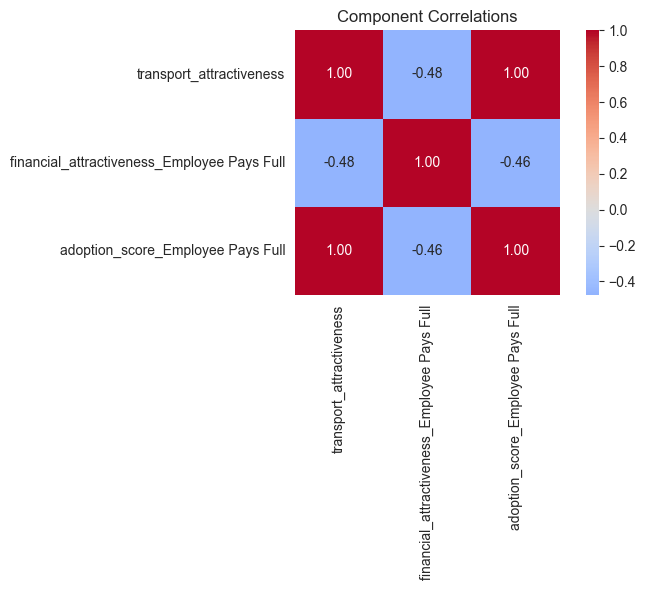

In [31]:
# Analyze correlations between transport attractiveness, financial attractiveness, and final adoption score
print("=== Component Correlations Analysis ===")

scenario = 'Employee Pays Full'
valid_data = commute_df[commute_df[f'adoption_score_{scenario}'].notna()]

correlations = valid_data[[
    'transport_attractiveness',
    f'financial_attractiveness_{scenario}',
    f'adoption_score_{scenario}'
]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlations, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f')
plt.title('Component Correlations')
plt.tight_layout()
plt.savefig('data/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

=== Optimal Station Rank Selection Analysis ===


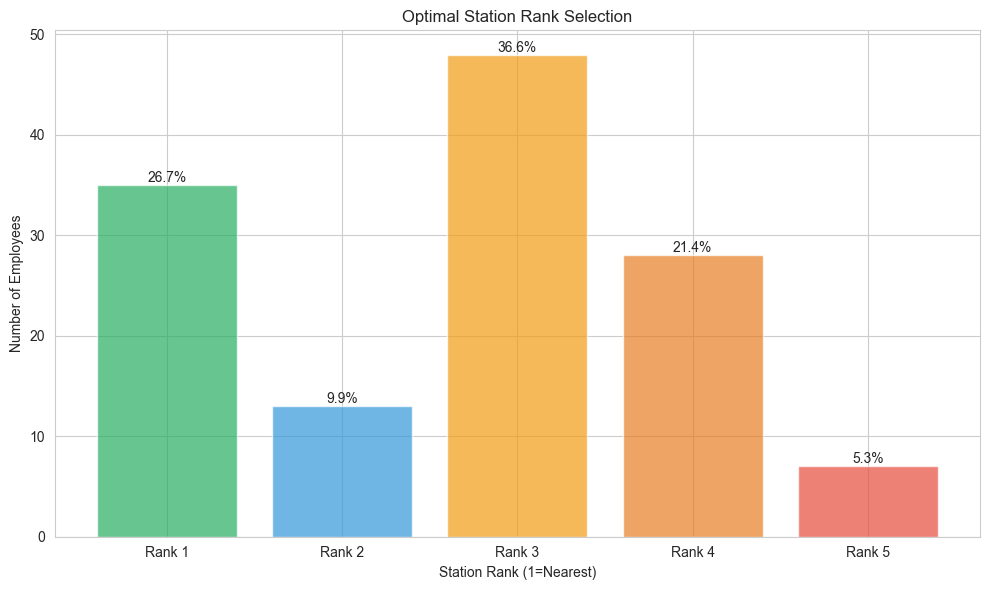

In [32]:
# Analyze which station ranks (1-5) were selected as optimal - this shows if the multi-candidate approach is valuable
print("=== Optimal Station Rank Selection Analysis ===")

rank_selection = valid_data['optimal_employee_station_rank'].value_counts().sort_index()
colors_rank = ['#27ae60', '#3498db', '#f39c12', '#e67e22', '#e74c3c']

plt.figure(figsize=(10, 6))
bars = plt.bar(range(1, 6), [rank_selection.get(i, 0) for i in range(1, 6)], 
               color=colors_rank, alpha=0.7)
plt.xlabel('Station Rank (1=Nearest)')
plt.ylabel('Number of Employees')
plt.title('Optimal Station Rank Selection')
plt.xticks(range(1, 6), ['Rank 1', 'Rank 2', 'Rank 3', 'Rank 4', 'Rank 5'])

# Add percentage labels on bars
for bar, rank in zip(bars, range(1, 6)):
    count = rank_selection.get(rank, 0)
    percentage = (count / len(valid_data) * 100)
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{percentage:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('data/station_rank_selection.png', dpi=300, bbox_inches='tight')
plt.show()

=== Average Component Scores ===


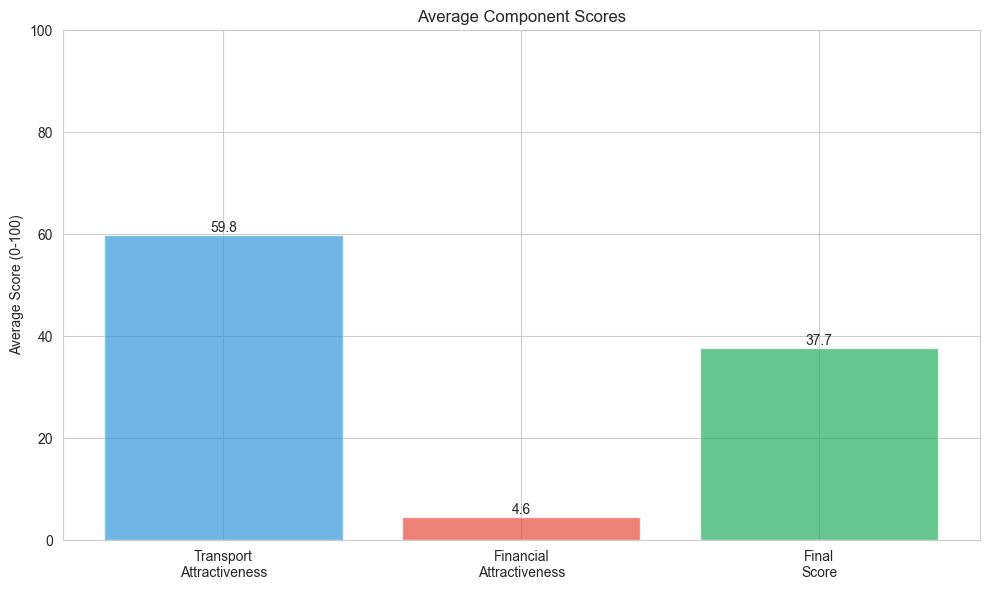

In [33]:
# Calculate and visualize average component scores
print("=== Average Component Scores ===")

components = ['Transport\nAttractiveness', 'Financial\nAttractiveness', 'Final\nScore']
avg_scores = [
    valid_data['transport_attractiveness'].mean(),
    valid_data[f'financial_attractiveness_{scenario}'].mean(),
    valid_data[f'adoption_score_{scenario}'].mean()
]

plt.figure(figsize=(10, 6))
bars = plt.bar(components, avg_scores, color=['#3498db', '#e74c3c', '#27ae60'], alpha=0.7)
plt.ylabel('Average Score (0-100)')
plt.title('Average Component Scores')
plt.ylim(0, 100)

# Add score labels on bars
for bar, score in zip(bars, avg_scores):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{score:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('data/component_scores.png', dpi=300, bbox_inches='tight')
plt.show()

=== Adoption Category Distribution ===


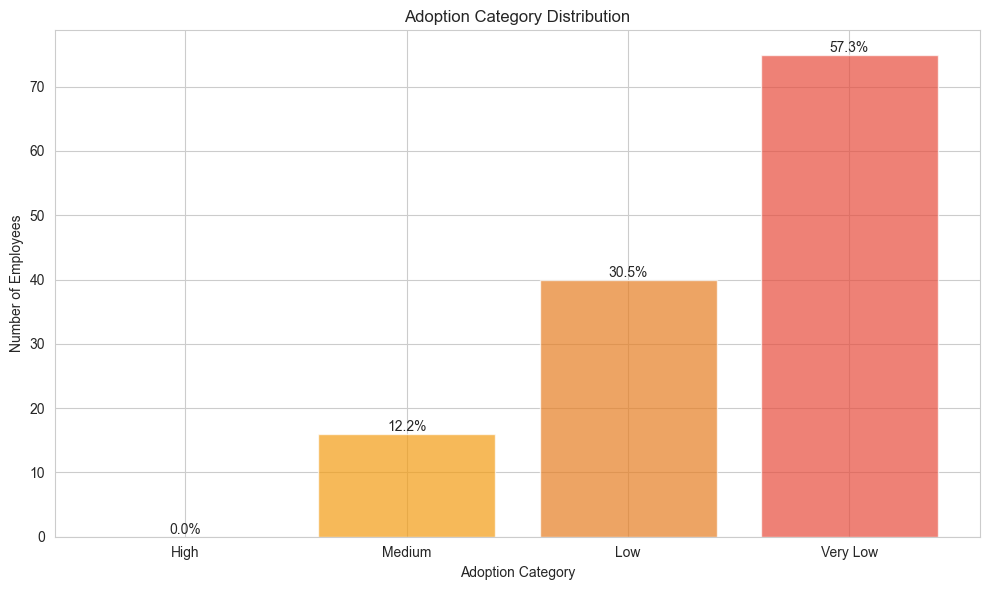

In [34]:
# Visualize adoption category distribution
print("=== Adoption Category Distribution ===")

category_counts = valid_data[f'adoption_category_{scenario}'].value_counts()
category_order = ['High', 'Medium', 'Low', 'Very Low']
category_data = [category_counts.get(cat, 0) for cat in category_order]
category_colors = ['#27ae60', '#f39c12', '#e67e22', '#e74c3c']

plt.figure(figsize=(10, 6))
bars = plt.bar(category_order, category_data, color=category_colors, alpha=0.7)
plt.xlabel('Adoption Category')
plt.ylabel('Number of Employees')
plt.title('Adoption Category Distribution')

# Add percentage labels on bars
for bar, count in zip(bars, category_data):
    percentage = (count / len(valid_data) * 100)
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{percentage:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('data/adoption_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
# Geographic analysis using existing car distance data to understand employee distribution
print("=== Geographic Analysis Using Existing Car Distance ===")

# Use ALL employees, not just those with PT routes
valid_data = commute_df.copy()

# Convert car distance from meters to km
valid_data['distance_to_office_km'] = valid_data['car_distance_m'] / 1000

print(f"Distance calculated for {len(valid_data)} employees")
print(f"Employees with PT routes: {valid_data['otp_route_found'].sum()}")
print(f"Employees without PT routes: {(~valid_data['otp_route_found']).sum()}")
print(f"Average distance: {valid_data['distance_to_office_km'].mean():.1f} km")
print(f"Distance range: {valid_data['distance_to_office_km'].min():.1f} - {valid_data['distance_to_office_km'].max():.1f} km")

=== Geographic Analysis Using Existing Car Distance ===
Distance calculated for 178 employees
Employees with PT routes: 131
Employees without PT routes: 47
Average distance: 24.4 km
Distance range: 2.8 - 64.2 km


In [36]:
# Categorize employees by distance ranges to understand geographic distribution
print("=== Categorize by Distance Ranges ===")

# Group by distance ranges
distance_ranges = [
    (0, 10, '0-10 km'),
    (10, 20, '10-20 km'),
    (20, 30, '20-30 km'),
    (30, 50, '30-50 km'),
    (50, float('inf'), '50+ km')
]

def categorize_distance(distance):
    for min_dist, max_dist, label in distance_ranges:
        if min_dist <= distance < max_dist:
            return label
    return '50+ km'

valid_data['distance_range'] = valid_data['distance_to_office_km'].apply(categorize_distance)

# Display distribution
distance_counts = valid_data['distance_range'].value_counts()
print("\nDistance distribution (ALL employees):")
for range_name in ['0-10 km', '10-20 km', '20-30 km', '30-50 km', '50+ km']:
    count = distance_counts.get(range_name, 0)
    percentage = (count / len(valid_data) * 100)
    print(f"{range_name}: {count} employees ({percentage:.1f}%)")

# Show PT vs non-PT by distance to understand where public transport is available
print("\nPT Route Availability by Distance:")
pt_availability_by_range = []
for range_name in ['0-10 km', '10-20 km', '20-30 km', '30-50 km', '50+ km']:
    subset = valid_data[valid_data['distance_range'] == range_name]
    pt_available = subset['otp_route_found'].sum()
    total = len(subset)
    pt_percentage = pt_available/total*100
    pt_availability_by_range.append(pt_percentage)
    print(f"{range_name}: {pt_available}/{total} have PT routes ({pt_percentage:.1f}%)")

=== Categorize by Distance Ranges ===

Distance distribution (ALL employees):
0-10 km: 22 employees (12.4%)
10-20 km: 54 employees (30.3%)
20-30 km: 27 employees (15.2%)
30-50 km: 70 employees (39.3%)
50+ km: 5 employees (2.8%)

PT Route Availability by Distance:
0-10 km: 2/22 have PT routes (9.1%)
10-20 km: 53/54 have PT routes (98.1%)
20-30 km: 7/27 have PT routes (25.9%)
30-50 km: 67/70 have PT routes (95.7%)
50+ km: 2/5 have PT routes (40.0%)


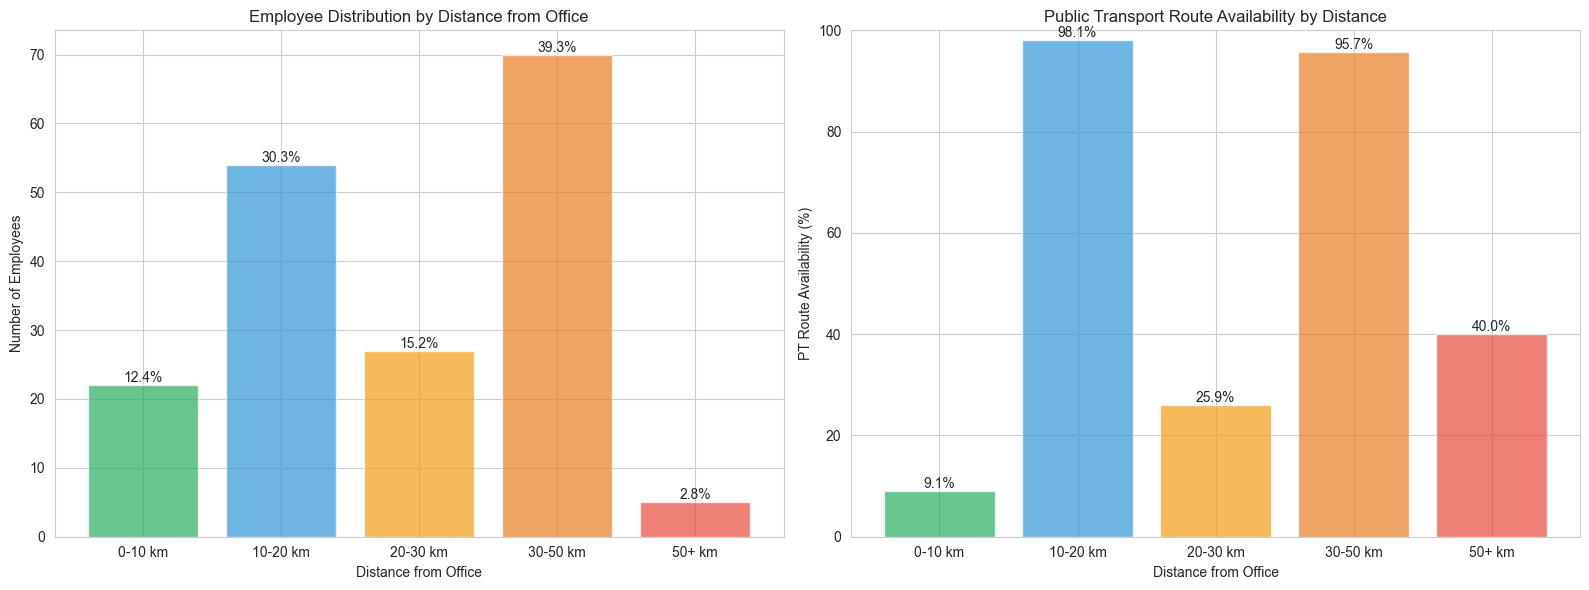

In [37]:
# Create visualization of distance distribution and PT route availability
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Distance distribution chart
distance_order = ['0-10 km', '10-20 km', '20-30 km', '30-50 km', '50+ km']
distance_data = [distance_counts.get(range_name, 0) for range_name in distance_order]
distance_colors = ['#27ae60', '#3498db', '#f39c12', '#e67e22', '#e74c3c']

bars1 = ax1.bar(distance_order, distance_data, color=distance_colors, alpha=0.7)
ax1.set_xlabel('Distance from Office')
ax1.set_ylabel('Number of Employees')
ax1.set_title('Employee Distribution by Distance from Office')

# Add percentage labels on bars
for bar, count in zip(bars1, distance_data):
    percentage = (count / len(valid_data) * 100)
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{percentage:.1f}%', ha='center', va='bottom')

# PT route availability chart
bars2 = ax2.bar(distance_order, pt_availability_by_range, color=distance_colors, alpha=0.7)
ax2.set_xlabel('Distance from Office')
ax2.set_ylabel('PT Route Availability (%)')
ax2.set_title('Public Transport Route Availability by Distance')
ax2.set_ylim(0, 100)

# Add percentage labels on bars
for bar, pct in zip(bars2, pt_availability_by_range):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{pct:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('data/distance_distribution_and_pt_availability.png', dpi=300, bbox_inches='tight')
plt.show()

=== Connectivity Quality Analysis by Distance (Round-Trip) ===


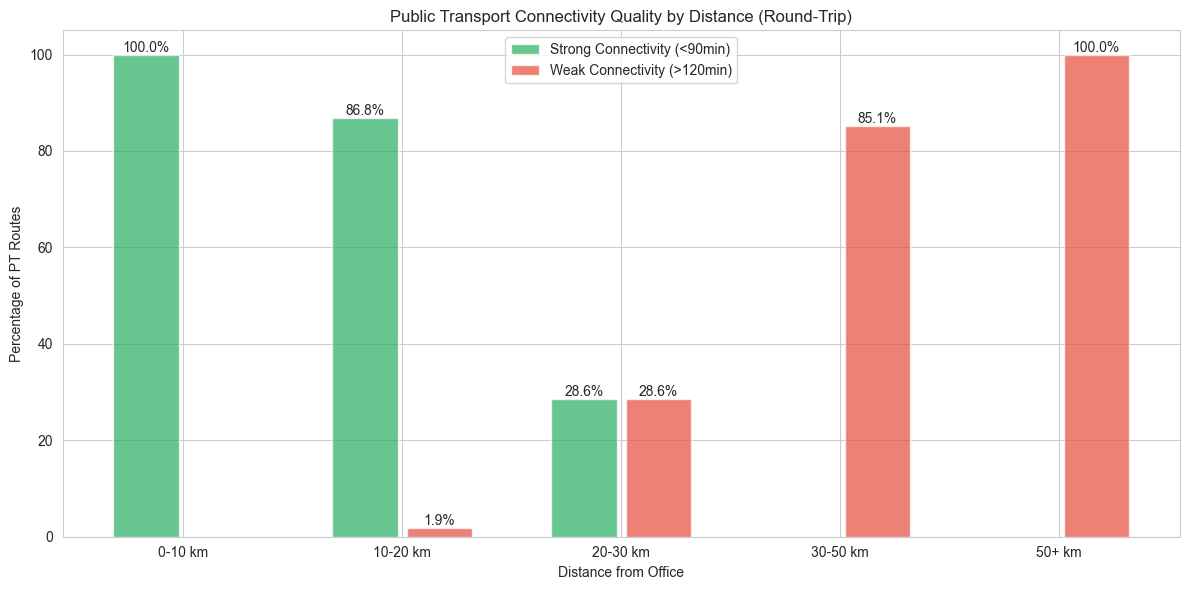


Detailed Connectivity Analysis by Distance (Round-Trip):

0-10 km:
  Total employees: 2
  PT routes available: 2 (100.0%)
  Average round-trip commute time: 21.1 min
  Strong connectivity (<90min): 2 (100.0%)
  Weak connectivity (>120min): 0 (0.0%)

10-20 km:
  Total employees: 53
  PT routes available: 53 (100.0%)
  Average round-trip commute time: 78.5 min
  Strong connectivity (<90min): 46 (86.8%)
  Weak connectivity (>120min): 1 (1.9%)

20-30 km:
  Total employees: 7
  PT routes available: 7 (100.0%)
  Average round-trip commute time: 108.3 min
  Strong connectivity (<90min): 2 (28.6%)
  Weak connectivity (>120min): 2 (28.6%)

30-50 km:
  Total employees: 67
  PT routes available: 67 (100.0%)
  Average round-trip commute time: 146.9 min
  Strong connectivity (<90min): 0 (0.0%)
  Weak connectivity (>120min): 57 (85.1%)

50+ km:
  Total employees: 2
  PT routes available: 2 (100.0%)
  Average round-trip commute time: 350.9 min
  Strong connectivity (<90min): 0 (0.0%)
  Weak connecti

In [38]:
# Analyze connectivity quality by distance - how well does public transport work at different distances?
print("=== Connectivity Quality Analysis by Distance (Round-Trip) ===")

# Redefine distance ranges for this analysis
distance_ranges = [
    (0, 10, '0-10 km'),
    (10, 20, '10-20 km'),
    (20, 30, '20-30 km'),
    (30, 50, '30-50 km'),
    (50, float('inf'), '50+ km')
]

distance_order = ['0-10 km', '10-20 km', '20-30 km', '30-50 km', '50+ km']

# Use valid data with PT routes
valid_data = commute_df[commute_df['otp_route_found']].copy()

# Calculate distance to office for valid_data
valid_data['distance_to_office_km'] = valid_data['car_distance_m'] / 1000

# Add distance range column
def get_distance_range(distance_km):
    for min_dist, max_dist, label in distance_ranges:
        if min_dist <= distance_km < max_dist:
            return label
    return '50+ km'

valid_data['distance_range'] = valid_data['distance_to_office_km'].apply(get_distance_range)

# Analyze connectivity quality by distance (using round-trip thresholds)
distance_analysis = []
for min_dist, max_dist, label in distance_ranges:
    subset = valid_data[valid_data['distance_range'] == label]
    if len(subset) > 0:
        total = len(subset)
        pt_available = subset['otp_route_found'].sum()
        pt_routes = subset[subset['otp_route_found']]
        
        if len(pt_routes) > 0:
            avg_commute = pt_routes['total_commute_min'].mean()
            strong_connectivity = len(pt_routes[pt_routes['total_commute_min'] < 90])  # Round-trip threshold
            weak_connectivity = len(pt_routes[pt_routes['total_commute_min'] > 120])  # Round-trip threshold
        else:
            avg_commute = None
            strong_connectivity = 0
            weak_connectivity = 0
        
        distance_analysis.append({
            'range': label,
            'total': total,
            'pt_available': pt_available,
            'pt_percentage': pt_available/total*100,
            'avg_commute': avg_commute,
            'strong_connectivity': strong_connectivity,
            'weak_connectivity': weak_connectivity
        })

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Connectivity strength by distance
strong_pct = [d['strong_connectivity']/d['pt_available']*100 if d['pt_available'] > 0 else 0 for d in distance_analysis]
weak_pct = [d['weak_connectivity']/d['pt_available']*100 if d['pt_available'] > 0 else 0 for d in distance_analysis]

x = np.arange(len(distance_order))
width = 0.30

# Add small offset to prevent perfect overlap
bars1 = ax.bar(x - width/2 - 0.02, strong_pct, width, label='Strong Connectivity (<90min)', color='#27ae60', alpha=0.7)
bars2 = ax.bar(x + width/2 + 0.02, weak_pct, width, label='Weak Connectivity (>120min)', color='#e74c3c', alpha=0.7)

ax.set_xlabel('Distance from Office')
ax.set_ylabel('Percentage of PT Routes')
ax.set_title('Public Transport Connectivity Quality by Distance (Round-Trip)')
ax.set_xticks(x)
ax.set_xticklabels(distance_order)
ax.legend()

# Add percentage labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('data/connectivity_quality_by_distance.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed analysis
print(f"\nDetailed Connectivity Analysis by Distance (Round-Trip):")
for d in distance_analysis:
    print(f"\n{d['range']}:")
    print(f"  Total employees: {d['total']}")
    print(f"  PT routes available: {d['pt_available']} ({d['pt_percentage']:.1f}%)")
    if d['avg_commute']:
        print(f"  Average round-trip commute time: {d['avg_commute']:.1f} min")
        print(f"  Strong connectivity (<90min): {d['strong_connectivity']} ({d['strong_connectivity']/d['pt_available']*100:.1f}%)")
        print(f"  Weak connectivity (>120min): {d['weak_connectivity']} ({d['weak_connectivity']/d['pt_available']*100:.1f}%)")

=== AREAS WITH STRONG VS. WEAK PUBLIC TRANSPORT CONNECTIVITY (ROUND-TRIP) ===
AREAS WITH STRONG PUBLIC TRANSPORT CONNECTIVITY:
  Definition: Round-trip commute time < 90 minutes
  Employees: 50 (38.2%)
  Average round-trip commute time: 73.3 minutes
  Average transport attractiveness: 76.6/100
  Geographic distribution:
    0-10 km: 2 employees
    10-20 km: 46 employees
    20-30 km: 2 employees

AREAS WHERE PUBLIC TRANSPORT IS LESS ATTRACTIVE:
  Definition: Round-trip commute time > 120 minutes
  Employees: 62 (47.3%)
  Average round-trip commute time: 158.7 minutes
  Average transport attractiveness: 42.9/100
  Geographic distribution:
    10-20 km: 1 employees
    20-30 km: 2 employees
    30-50 km: 57 employees
    50+ km: 2 employees

NO PUBLIC TRANSPORT AVAILABLE:
  Employees: 47 (26.4%)
  These employees rely on car or alternative transportation


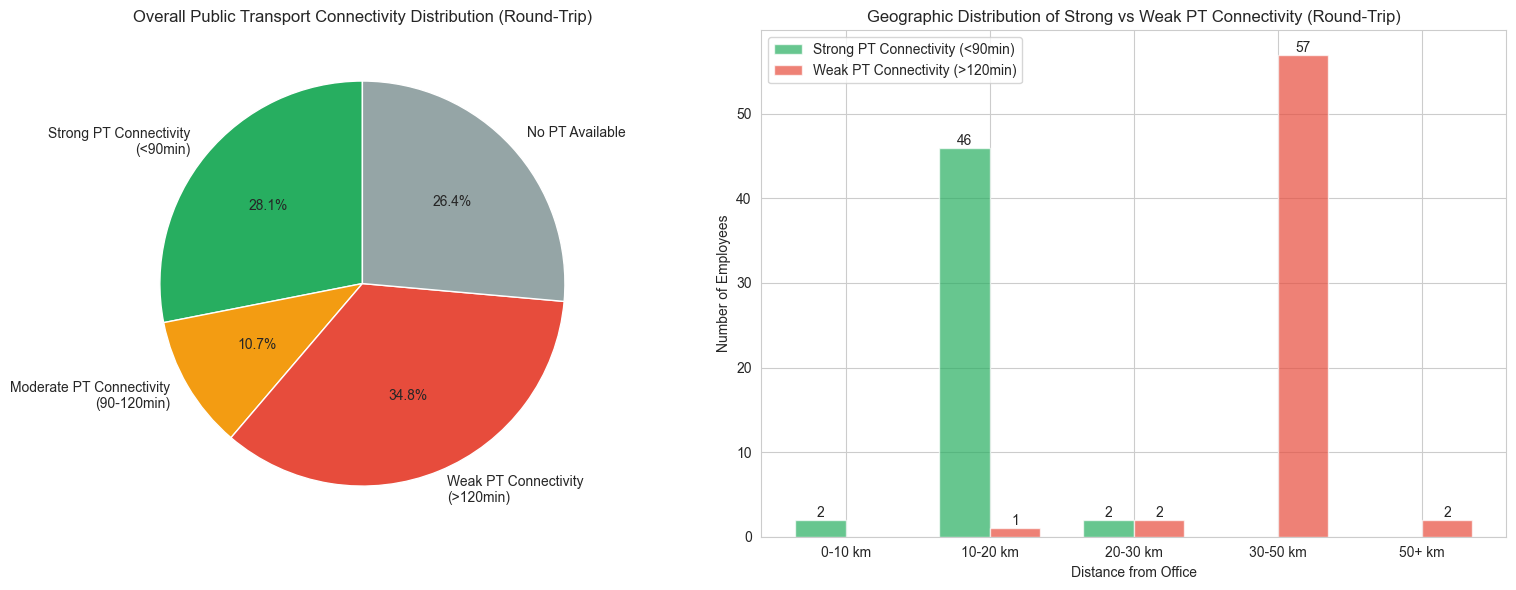

In [39]:
# Final summary comparing strong vs weak public transport connectivity areas (round-trip)
print("=== AREAS WITH STRONG VS. WEAK PUBLIC TRANSPORT CONNECTIVITY (ROUND-TRIP) ===")

# Use valid data with PT routes
valid_data = commute_df[commute_df['otp_route_found']].copy()

# Calculate distance to office for valid_data
valid_data['distance_to_office_km'] = valid_data['car_distance_m'] / 1000

# Define strong connectivity areas (round-trip < 90 min) and weak connectivity areas (round-trip > 120 min)
strong_connectivity = valid_data[valid_data['total_commute_min'] < 90]
weak_connectivity = valid_data[valid_data['total_commute_min'] > 120]

print(f"AREAS WITH STRONG PUBLIC TRANSPORT CONNECTIVITY:")
print(f"  Definition: Round-trip commute time < 90 minutes")
print(f"  Employees: {len(strong_connectivity)} ({len(strong_connectivity)/len(valid_data)*100:.1f}%)")
print(f"  Average round-trip commute time: {strong_connectivity['total_commute_min'].mean():.1f} minutes")
print(f"  Average transport attractiveness: {strong_connectivity['transport_attractiveness'].mean():.1f}/100")
print(f"  Geographic distribution:")

# Define distance ranges for geographic distribution
distance_ranges = [
    (0, 10, '0-10 km'),
    (10, 20, '10-20 km'),
    (20, 30, '20-30 km'),
    (30, 50, '30-50 km'),
    (50, float('inf'), '50+ km')
]

# Geographic distribution of strong connectivity
for min_dist, max_dist, label in distance_ranges:
    subset = strong_connectivity[
        (strong_connectivity['distance_to_office_km'] >= min_dist) & 
        (strong_connectivity['distance_to_office_km'] < max_dist)
    ]
    if len(subset) > 0:
        print(f"    {label}: {len(subset)} employees")

print(f"\nAREAS WHERE PUBLIC TRANSPORT IS LESS ATTRACTIVE:")
print(f"  Definition: Round-trip commute time > 120 minutes")
print(f"  Employees: {len(weak_connectivity)} ({len(weak_connectivity)/len(valid_data)*100:.1f}%)")
print(f"  Average round-trip commute time: {weak_connectivity['total_commute_min'].mean():.1f} minutes")
print(f"  Average transport attractiveness: {weak_connectivity['transport_attractiveness'].mean():.1f}/100")
print(f"  Geographic distribution:")

# Geographic distribution of weak connectivity
for min_dist, max_dist, label in distance_ranges:
    subset = weak_connectivity[
        (weak_connectivity['distance_to_office_km'] >= min_dist) & 
        (weak_connectivity['distance_to_office_km'] < max_dist)
    ]
    if len(subset) > 0:
        print(f"    {label}: {len(subset)} employees")

print(f"\nNO PUBLIC TRANSPORT AVAILABLE:")
print(f"  Employees: {(~commute_df['otp_route_found']).sum()} ({(~commute_df['otp_route_found']).sum()/len(commute_df)*100:.1f}%)")
print(f"  These employees rely on car or alternative transportation")

# Create visualization for overall connectivity distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart showing overall connectivity distribution
categories = ['Strong PT Connectivity\n(<90min)', 'Moderate PT Connectivity\n(90-120min)', 'Weak PT Connectivity\n(>120min)', 'No PT Available']
strong_count = len(strong_connectivity)
moderate_count = len(valid_data[(valid_data['total_commute_min'] >= 90) & (valid_data['total_commute_min'] <= 120)])
weak_count = len(weak_connectivity)
no_pt_count = (~commute_df['otp_route_found']).sum()

sizes = [strong_count, moderate_count, weak_count, no_pt_count]
colors = ['#27ae60', '#f39c12', '#e74c3c', '#95a5a6']

ax1.pie(sizes, labels=categories, autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Overall Public Transport Connectivity Distribution (Round-Trip)')

# Bar chart showing geographic distribution of strong vs weak connectivity
geo_data = {
    'Strong PT': [],
    'Weak PT': []
}

for min_dist, max_dist, label in distance_ranges:
    strong_subset = strong_connectivity[
        (strong_connectivity['distance_to_office_km'] >= min_dist) & 
        (strong_connectivity['distance_to_office_km'] < max_dist)
    ]
    weak_subset = weak_connectivity[
        (weak_connectivity['distance_to_office_km'] >= min_dist) & 
        (weak_connectivity['distance_to_office_km'] < max_dist)
    ]
    geo_data['Strong PT'].append(len(strong_subset))
    geo_data['Weak PT'].append(len(weak_subset))

x = np.arange(len(distance_ranges))
width = 0.35

bars1 = ax2.bar(x - width/2, geo_data['Strong PT'], width, label='Strong PT Connectivity (<90min)', color='#27ae60', alpha=0.7)
bars2 = ax2.bar(x + width/2, geo_data['Weak PT'], width, label='Weak PT Connectivity (>120min)', color='#e74c3c', alpha=0.7)

ax2.set_xlabel('Distance from Office')
ax2.set_ylabel('Number of Employees')
ax2.set_title('Geographic Distribution of Strong vs Weak PT Connectivity (Round-Trip)')
ax2.set_xticks(x)
ax2.set_xticklabels([label for _, _, label in distance_ranges])
ax2.legend()

# Add count labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('data/strong_weak_connectivity_overview.png', dpi=300, bbox_inches='tight')
plt.show()

In [40]:
# Final summary of all findings (round-trip analysis)
print("=== FINAL SUMMARY FINDINGS (ROUND-TRIP) ===")
print("=" * 60)

# Use valid data with PT routes
valid_data = commute_df[commute_df['otp_route_found']].copy()

# Calculate distance for valid_data
valid_data['distance_to_office_km'] = valid_data['car_distance_m'] / 1000

# 1. Commute-Time Distribution (Round-Trip)
print(f"\n1. ROUND-TRIP COMMUTE-TIME DISTRIBUTION:")
print(f"   Total employees: {len(commute_df)}")
print(f"   Employees with valid routes: {len(valid_data)} ({len(valid_data)/len(commute_df)*100:.1f}%)")
print(f"   Employees without routes: {(~commute_df['otp_route_found']).sum()} ({(~commute_df['otp_route_found']).sum()/len(commute_df)*100:.1f}%)")

bucket_counts = valid_data['commute_time_bucket'].value_counts()
for bucket in ['0-60 min', '60-90 min', '90-120 min', '120+ min']:
    count = bucket_counts.get(bucket, 0)
    percentage = count / len(valid_data) * 100
    print(f"   - {bucket}: {count} ({percentage:.1f}%)")

# 2. Deutschlandticket Adoption Potential by Scenario
print(f"\n2. DEUTSCHLANDTICKET ADOPTION POTENTIAL BY SCENARIO:")

scenario = 'Employee Pays Full'
adoption_counts = commute_df[f'adoption_category_{scenario}'].value_counts()
total_with_scores = len(commute_df[commute_df[f'adoption_score_{scenario}'].notna()])

print(f"\n   {scenario}:")
print(f"   Employee cost: €{scenarios[scenario]['employee_cost']}")
print(f"   High: {adoption_counts.get('High', 0)} ({adoption_counts.get('High', 0)/total_with_scores*100:.1f}%)")
print(f"   Medium: {adoption_counts.get('Medium', 0)} ({adoption_counts.get('Medium', 0)/total_with_scores*100:.1f}%)")
print(f"   Low: {adoption_counts.get('Low', 0)} ({adoption_counts.get('Low', 0)/total_with_scores*100:.1f}%)")
print(f"   Very Low: {adoption_counts.get('Very Low', 0)} ({adoption_counts.get('Very Low', 0)/total_with_scores*100:.1f}%)")
print(f"   No route data: {adoption_counts.get('No route data', 0)} ({adoption_counts.get('No route data', 0)/len(commute_df)*100:.1f}%)")

print(f"\n   Note: All three cost scenarios (Company Pays Full, 50% Subsidy, Employee Pays Full)")
print(f"   show identical adoption results because the cost advantage of public transport")
print(f"   over driving is so large (€280/month average savings) that who pays doesn't")
print(f"   differentiate the financial attractiveness.")

# 3. Key Factors Driving Adoption
print(f"\n3. KEY FACTORS DRIVING ADOPTION (ROUND-TRIP):")
print(f"   Average transport attractiveness: {valid_data['transport_attractiveness'].mean():.1f}/100")
print(f"   Average financial attractiveness: {valid_data[f'financial_attractiveness_{scenario}'].mean():.1f}/100")
print(f"   Average monthly driving cost: €{valid_data['monthly_driving_cost'].mean():.0f}")
print(f"   Average Deutschlandticket cost: €{scenarios[scenario]['employee_cost']}")
print(f"   Average monthly savings: €{valid_data[f'monthly_savings_{scenario}'].mean():.0f}")

# 4. Geographic Connectivity Analysis (Round-Trip)
print(f"\n4. GEOGRAPHIC CONNECTIVITY ANALYSIS (ROUND-TRIP):")

# Define strong/weak connectivity (round-trip thresholds)
strong_connectivity = valid_data[valid_data['total_commute_min'] < 90]
weak_connectivity = valid_data[valid_data['total_commute_min'] > 120]

print(f"\n   AREAS WITH STRONG PUBLIC TRANSPORT CONNECTIVITY:")
print(f"   Definition: Round-trip commute time < 90 minutes")
print(f"   Employees: {len(strong_connectivity)} ({len(strong_connectivity)/len(valid_data)*100:.1f}%)")
print(f"   Average round-trip commute time: {strong_connectivity['total_commute_min'].mean():.1f} minutes")
print(f"   Average transport attractiveness: {strong_connectivity['transport_attractiveness'].mean():.1f}/100")

print(f"\n   AREAS WHERE PUBLIC TRANSPORT IS LESS ATTRACTIVE:")
print(f"   Definition: Round-trip commute time > 120 minutes")
print(f"   Employees: {len(weak_connectivity)} ({len(weak_connectivity)/len(valid_data)*100:.1f}%)")
print(f"   Average round-trip commute time: {weak_connectivity['total_commute_min'].mean():.1f} minutes")
print(f"   Average transport attractiveness: {weak_connectivity['transport_attractiveness'].mean():.1f}/100")

print(f"\n   NO PUBLIC TRANSPORT AVAILABLE:")
print(f"   Employees: {(~commute_df['otp_route_found']).sum()} ({(~commute_df['otp_route_found']).sum()/len(commute_df)*100:.1f}%)")
print(f"   These employees rely on car or alternative transportation")

# 5. Generated Visualizations
print(f"\n5. GENERATED VISUALIZATIONS:")
print(f"   - data/commute_time_distribution.png (round-trip)")
print(f"   - data/correlation_heatmap.png")
print(f"   - data/station_rank_selection.png")
print(f"   - data/component_scores.png")
print(f"   - data/adoption_distribution.png")
print(f"   - data/distance_distribution_and_pt_availability.png")
print(f"   - data/connectivity_quality_by_distance.png (round-trip)")

print(f"\n" + "=" * 60)
print(f"ANALYSIS COMPLETE (ROUND-TRIP COMMUTE TIMES)")

=== FINAL SUMMARY FINDINGS (ROUND-TRIP) ===

1. ROUND-TRIP COMMUTE-TIME DISTRIBUTION:
   Total employees: 178
   Employees with valid routes: 131 (73.6%)
   Employees without routes: 47 (26.4%)
   - 0-60 min: 7 (5.3%)
   - 60-90 min: 43 (32.8%)
   - 90-120 min: 19 (14.5%)
   - 120+ min: 62 (47.3%)

2. DEUTSCHLANDTICKET ADOPTION POTENTIAL BY SCENARIO:

   Employee Pays Full:
   Employee cost: €63
   High: 0 (0.0%)
   Medium: 16 (12.2%)
   Low: 40 (30.5%)
   Very Low: 75 (57.3%)
   No route data: 47 (26.4%)

   Note: All three cost scenarios (Company Pays Full, 50% Subsidy, Employee Pays Full)
   show identical adoption results because the cost advantage of public transport
   over driving is so large (€280/month average savings) that who pays doesn't
   differentiate the financial attractiveness.

3. KEY FACTORS DRIVING ADOPTION (ROUND-TRIP):
   Average transport attractiveness: 59.8/100
   Average financial attractiveness: 4.6/100
   Average monthly driving cost: €212
   Average Deutsc